In [31]:
# load a coffea file
from coffea.util import load
import os
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
import matplotlib
matplotlib.rcParams["figure.dpi"] = 300
import matplotlib as mpl

import vector
vector.register_awkward

<function vector.register_awkward() -> 'None'>

In [56]:
def plot_reweighted_scores(vals1, vals2, range1=[0.65, 1], range2=[0.1, 0.65], regnames=["sig", "c-region"], label="SubLeadingHiggs bb-score reweighted from region to [0,1]"):
    range_c = [0.1, 0.65]
    ragne_sig = [0.65, 1]
    
    conv1 = lambda x: (0.65+(x-range1[0]*(1.0-0.65)/(range1[1]-range1[0])))
    conv2 = lambda x: (0.65+(x-range2[0]*(1.0-0.65)/(range2[1]-range2[0])))
    print(conv1(0.1))
    print(conv1(0.65))
    print(conv2(0.65))
    print(conv2(1))
    sig_bscore_conv = conv1(vals1)
    c_reg_bscore_conv = conv2(vals2)
    
    
    
    bins = np.linspace(0.65,1,40)
    h_sig, edges_sig = np.histogram(sig_bscore_conv, bins)
    h_c, edges_c = np.histogram(c_reg_bscore_conv, bins)
    print(h_sig)
    print(h_c)
    assert all(edges_sig == edges_c)
    edges = edges_sig
    centers = 0.5 * (edges[:-1] + edges[1:])
    ratio = np.divide(h_sig, h_c, out=np.zeros_like(h_sig, dtype=float), where=h_c!=0)
    
    d1 = h_sig / (h_sig.sum() * np.diff(bins))
    d2 = h_c / (h_c.sum() * np.diff(bins))
    
    # --- Statistical errors (Poisson) ---
    err1 = np.sqrt(h_sig) / (h_sig.sum() * np.diff(bins))
    err2 = np.sqrt(h_c) / (h_c.sum() * np.diff(bins))
    
    # --- Ratio and propagated error ---
    ratio = np.divide(d1, d2, out=np.zeros_like(d1), where=d2 != 0)
    
    # error propagation: (A/B)
    ratio_err = np.zeros_like(ratio)
    mask = (d1 > 0) & (d2 > 0)
    
    ratio_err[mask] = ratio[mask] * np.sqrt(
        (err1[mask] / d1[mask])**2) #+
        #(err2[mask] / d2[mask])**2
    #)
    rel_err2 = np.zeros_like(d2)
    rel_err2[mask] = err2[mask] / d2[mask]
    band_low = 1.0 -rel_err2
    band_high = 1.0 + rel_err2
    
    fig, (ax_top, ax_ratio) = plt.subplots(
        2, 1, sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )
    col1 = "tab:blue"
    col2 = "tab:orange"
    
    # Top: histograms
    ax_top.hist(sig_bscore_conv, histtype="step", bins=bins, alpha=0.5, label="signal region", density=True, color=col1)
    ax_top.hist(c_reg_bscore_conv, histtype="step", bins=bins, alpha=0.5, label="C region", density=True, color=col2)
    ax_top.set_ylabel("Counts density")
    ax_top.legend()
    
    ax_top.errorbar(centers, d1, yerr=err1,
                    fmt=".", color=col1, ms=3)
    ax_top.errorbar(centers, d2, yerr=err2,
                    fmt=".", color=col2, ms=3)
    
    # Bottom: ratio
    ax_ratio.errorbar(centers, ratio, yerr=ratio_err,
                      fmt=".", color=col1, ms=3)
    
    ax_ratio.fill_between(
        centers,
        band_low,
        band_high,
        step="mid",        # matches histogram binning nicely
        color=col2,      # same color as h2
        alpha=0.25,
        linewidth=0
    )
    ax_ratio.axhline(1.0, color=col2)  # reference line
    ax_ratio.set_xlabel(label)
    ax_ratio.set_ylabel(f"{regnames[0]} / {regnames[1]}")
    
    plt.tight_layout()
    plt.show()

In [57]:
input = "/work/bevila_t/PostDoc/HH4b/Output/PocketCoffea/test_fatjets_training_et_ttbar/output_all.coffea"

o = load(f"{input}")
# print(o)
# print(o["columns"])
samples=list(o["columns"].keys())
# print(f"Samples {samples}")
# for sample in samples:
#     datasets=list(o["columns"][sample].keys())
#     print(f"Datasets {datasets}")
#     for dataset in datasets:
#         categories=list(o["columns"][sample][dataset].keys())
#         print(f"Categories {categories}")
#         for category in categories:
#             variations=o["columns"][sample][dataset][category].keys()
#             for var in variations:
#                 print(f"Category: {category}")
#                 print(f"Variation: {var}")
#                 col=o["columns"][sample][dataset][category]#[var]
#                 print(f"Columns {col.keys()}")
#                 print(col["weight"])

# Fix the columns I want:
sample = samples[0]
dataset =list(o["columns"][sample].keys())[0]
categories=list(o["columns"][sample][dataset].keys())

print(sample)
print(dataset)
print(categories)

col_4b = o["columns"][sample][dataset][categories[0]]


DATA_JetMET_JMENano_E_boosted_skimmed
DATA_JetMET_JMENano_E_2022_postEE_EraE
['boosted_signal_region', 'boosted_ttbar_region', 'boosted_vbf_region', 'boosted_qcd_A_region', 'boosted_qcd_B_region', 'boosted_qcd_C_region']


In [58]:
print(samples)
print(dataset)
print(categories)

['DATA_JetMET_JMENano_E_boosted_skimmed', 'DATA_JetMET_JMENano_F_boosted_skimmed', 'DATA_JetMET_JMENano_G_boosted_skimmed', 'TTto2L2Nu_skimmed', 'TTto4Q_skimmed', 'TTtoLNu2Q_skimmed']
DATA_JetMET_JMENano_E_2022_postEE_EraE
['boosted_signal_region', 'boosted_ttbar_region', 'boosted_vbf_region', 'boosted_qcd_A_region', 'boosted_qcd_B_region', 'boosted_qcd_C_region']


In [59]:
sig_bscore=o["columns"][samples[1]][list(o["columns"][samples[1]].keys())[0]]['boosted_signal_region']["HiggsSubLeading_btagBB"].value
c_bscore=o["columns"][samples[1]][list(o["columns"][samples[1]].keys())[0]]['boosted_qcd_C_region']["HiggsSubLeading_btagBB"].value
b_bscore=o["columns"][samples[1]][list(o["columns"][samples[1]].keys())[0]]['boosted_qcd_B_region']["HiggsSubLeading_btagBB"].value
a_bscore=o["columns"][samples[1]][list(o["columns"][samples[1]].keys())[0]]['boosted_qcd_A_region']["HiggsSubLeading_btagBB"].value

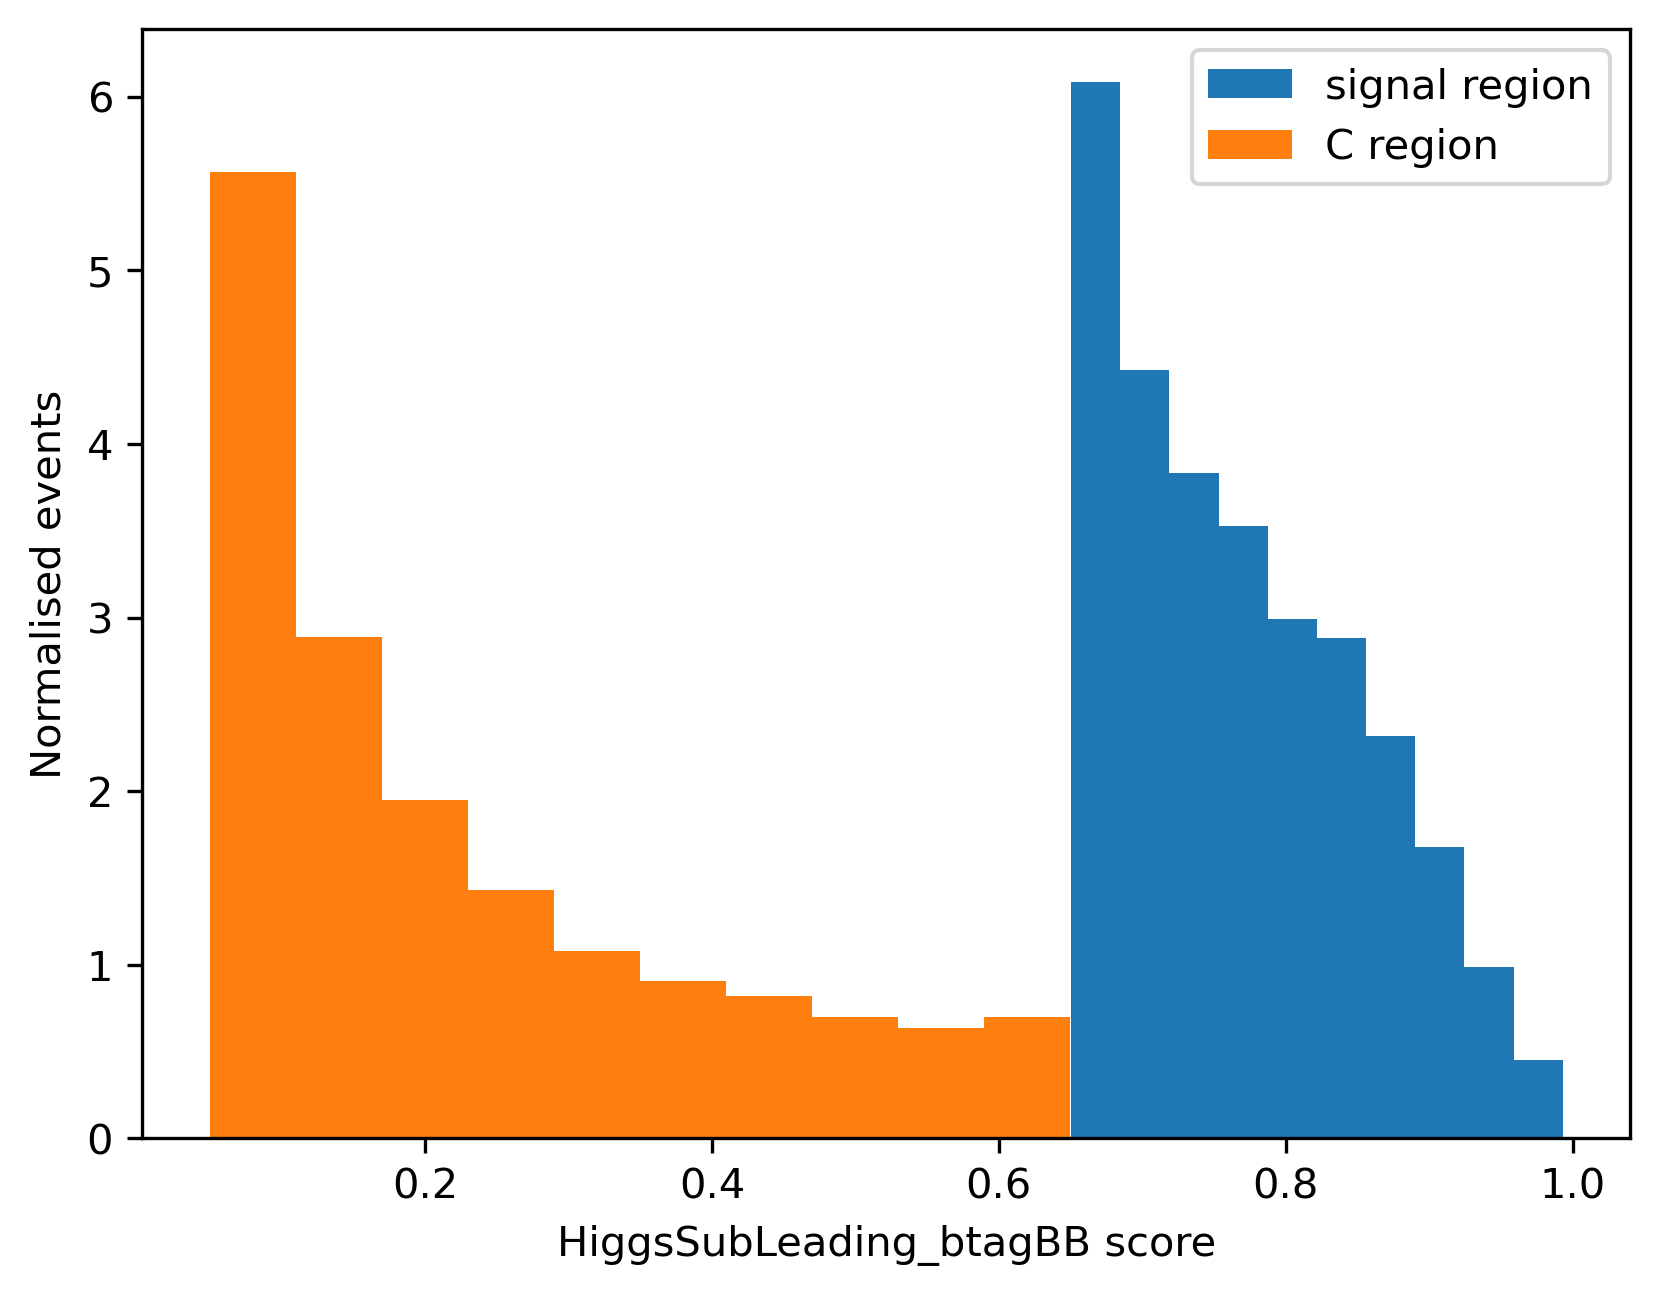

In [60]:
plt.figure()
plt.hist(sig_bscore, label="signal region", density=True)
plt.hist(c_bscore, label="C region", density=True)
plt.xlabel("HiggsSubLeading_btagBB score")
plt.ylabel("Normalised events")
plt.legend()

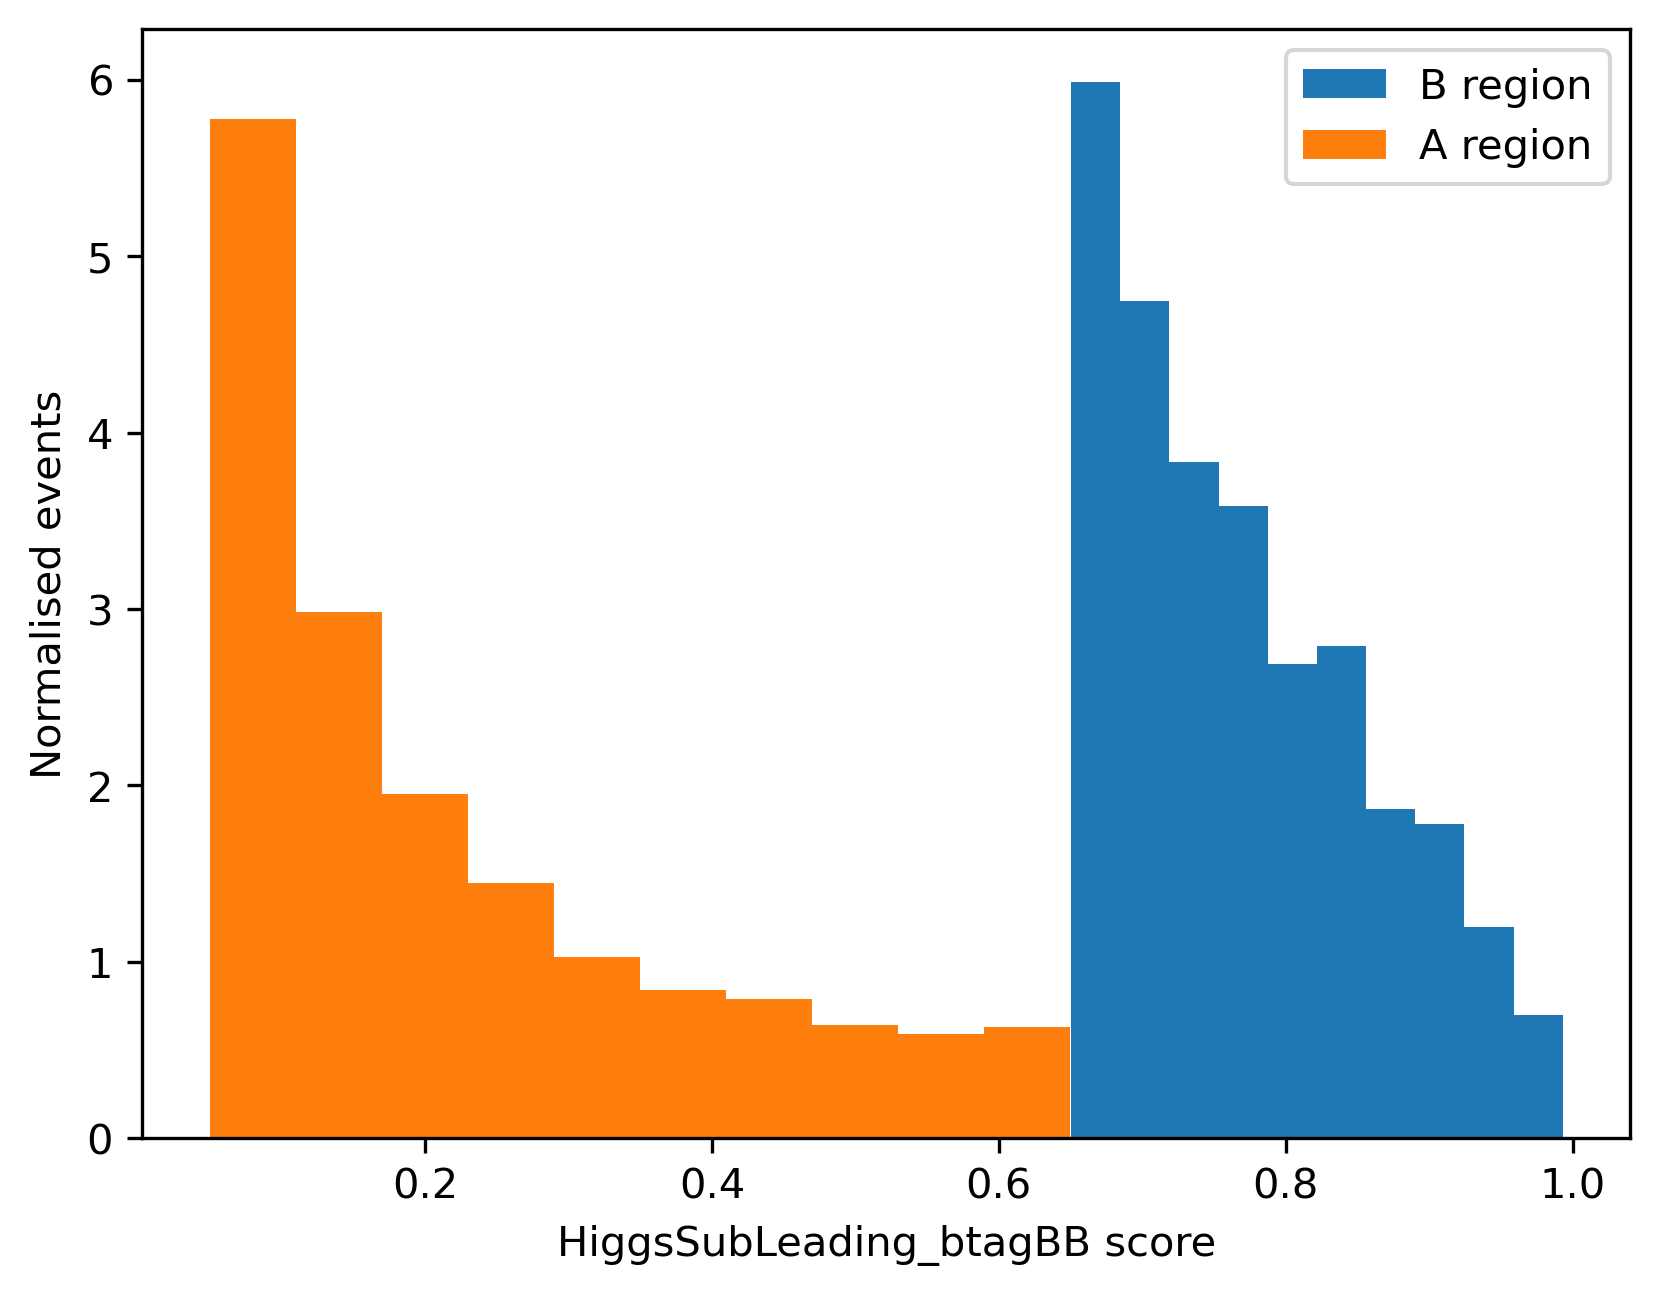

In [61]:
plt.figure()
plt.hist(b_bscore, label="B region", density=True)
plt.hist(a_bscore, label="A region", density=True)
plt.xlabel("HiggsSubLeading_btagBB score")
plt.ylabel("Normalised events")
plt.legend()

0.09999999999999998
0.65
1.2363636363636363
1.5863636363636364
[241 233 240 213 200 163 150 162 157 150 168 126 150 145 126 136 106 125
 107  93 118 104 122 112  82  77  93  68  73  52  56  51  32  32  35  16
  18  11   1]
[2239 1980 1728 1517 1436 1273 1169 1148 1039  995  954  809  792  732
  784  672  662  655  605  593  575  518  514  463  444  440  436  395
  363  380  391  364  344  335  336  309  318  320  342]


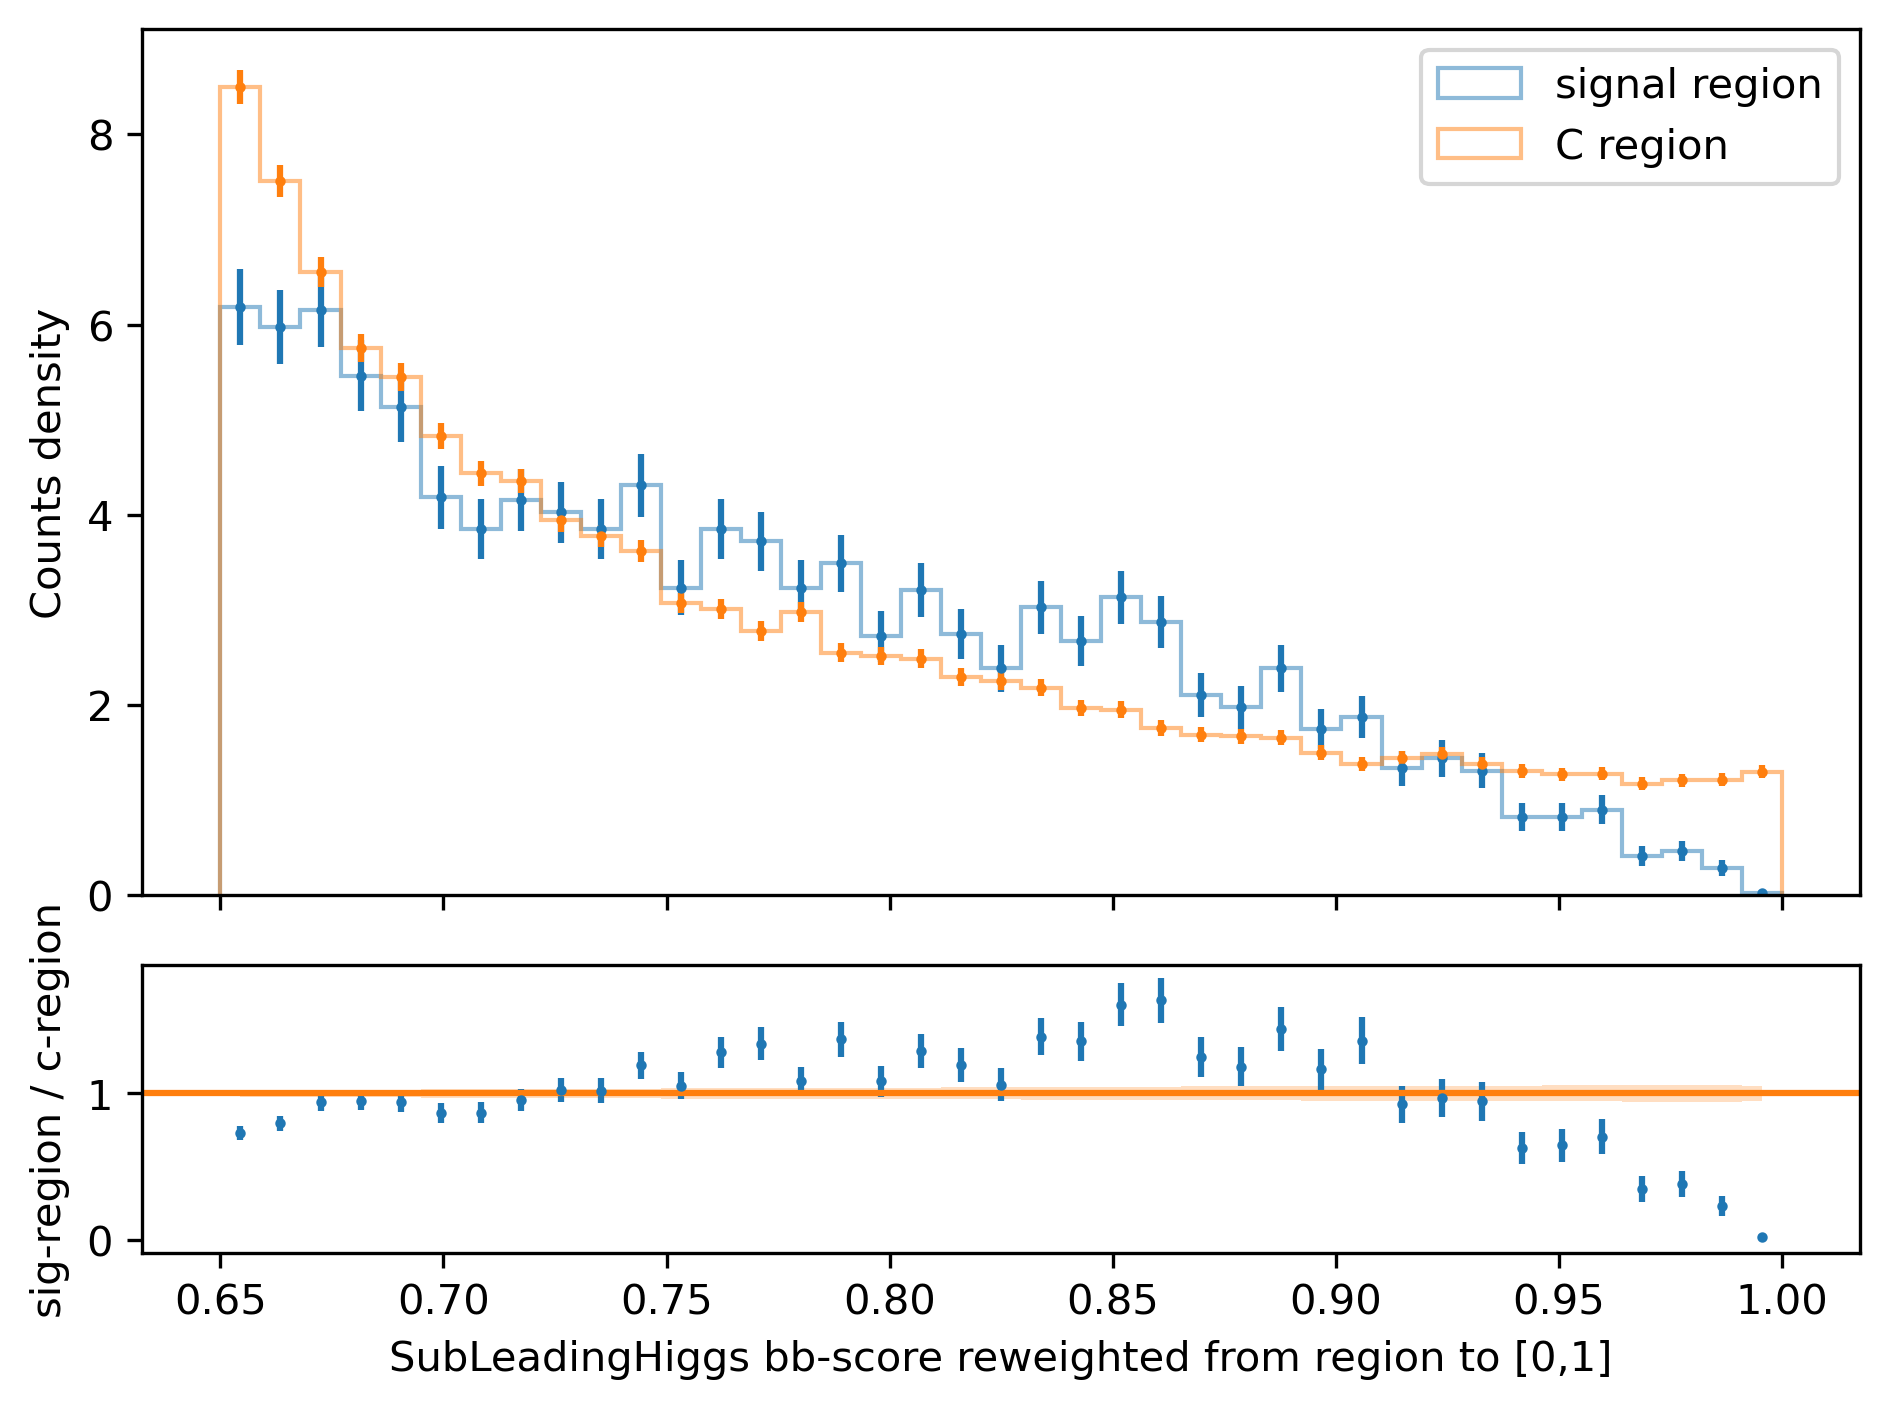

In [62]:
plot_reweighted_scores(sig_bscore, c_bscore, range1=[0.65, 1], range2=[0.1, 0.65], regnames=["sig-region", "c-region"], label="SubLeadingHiggs bb-score reweighted from region to [0,1]")

0.09999999999999998
0.65
1.2363636363636363
1.5863636363636364
[214 194 195 149 166 173 143 138 116 110 130 130 146 112 104  89  85  87
  85  88  76  94  97  63  58  57  67  55  69  50  51  43  45  36  26  31
  21  11   2]
[2141 2042 1660 1547 1440 1257 1170 1099  999  980  945  847  810  719
  720  647  617  587  571  534  541  509  504  472  450  411  394  369
  346  325  341  321  332  287  325  266  256  276  304]


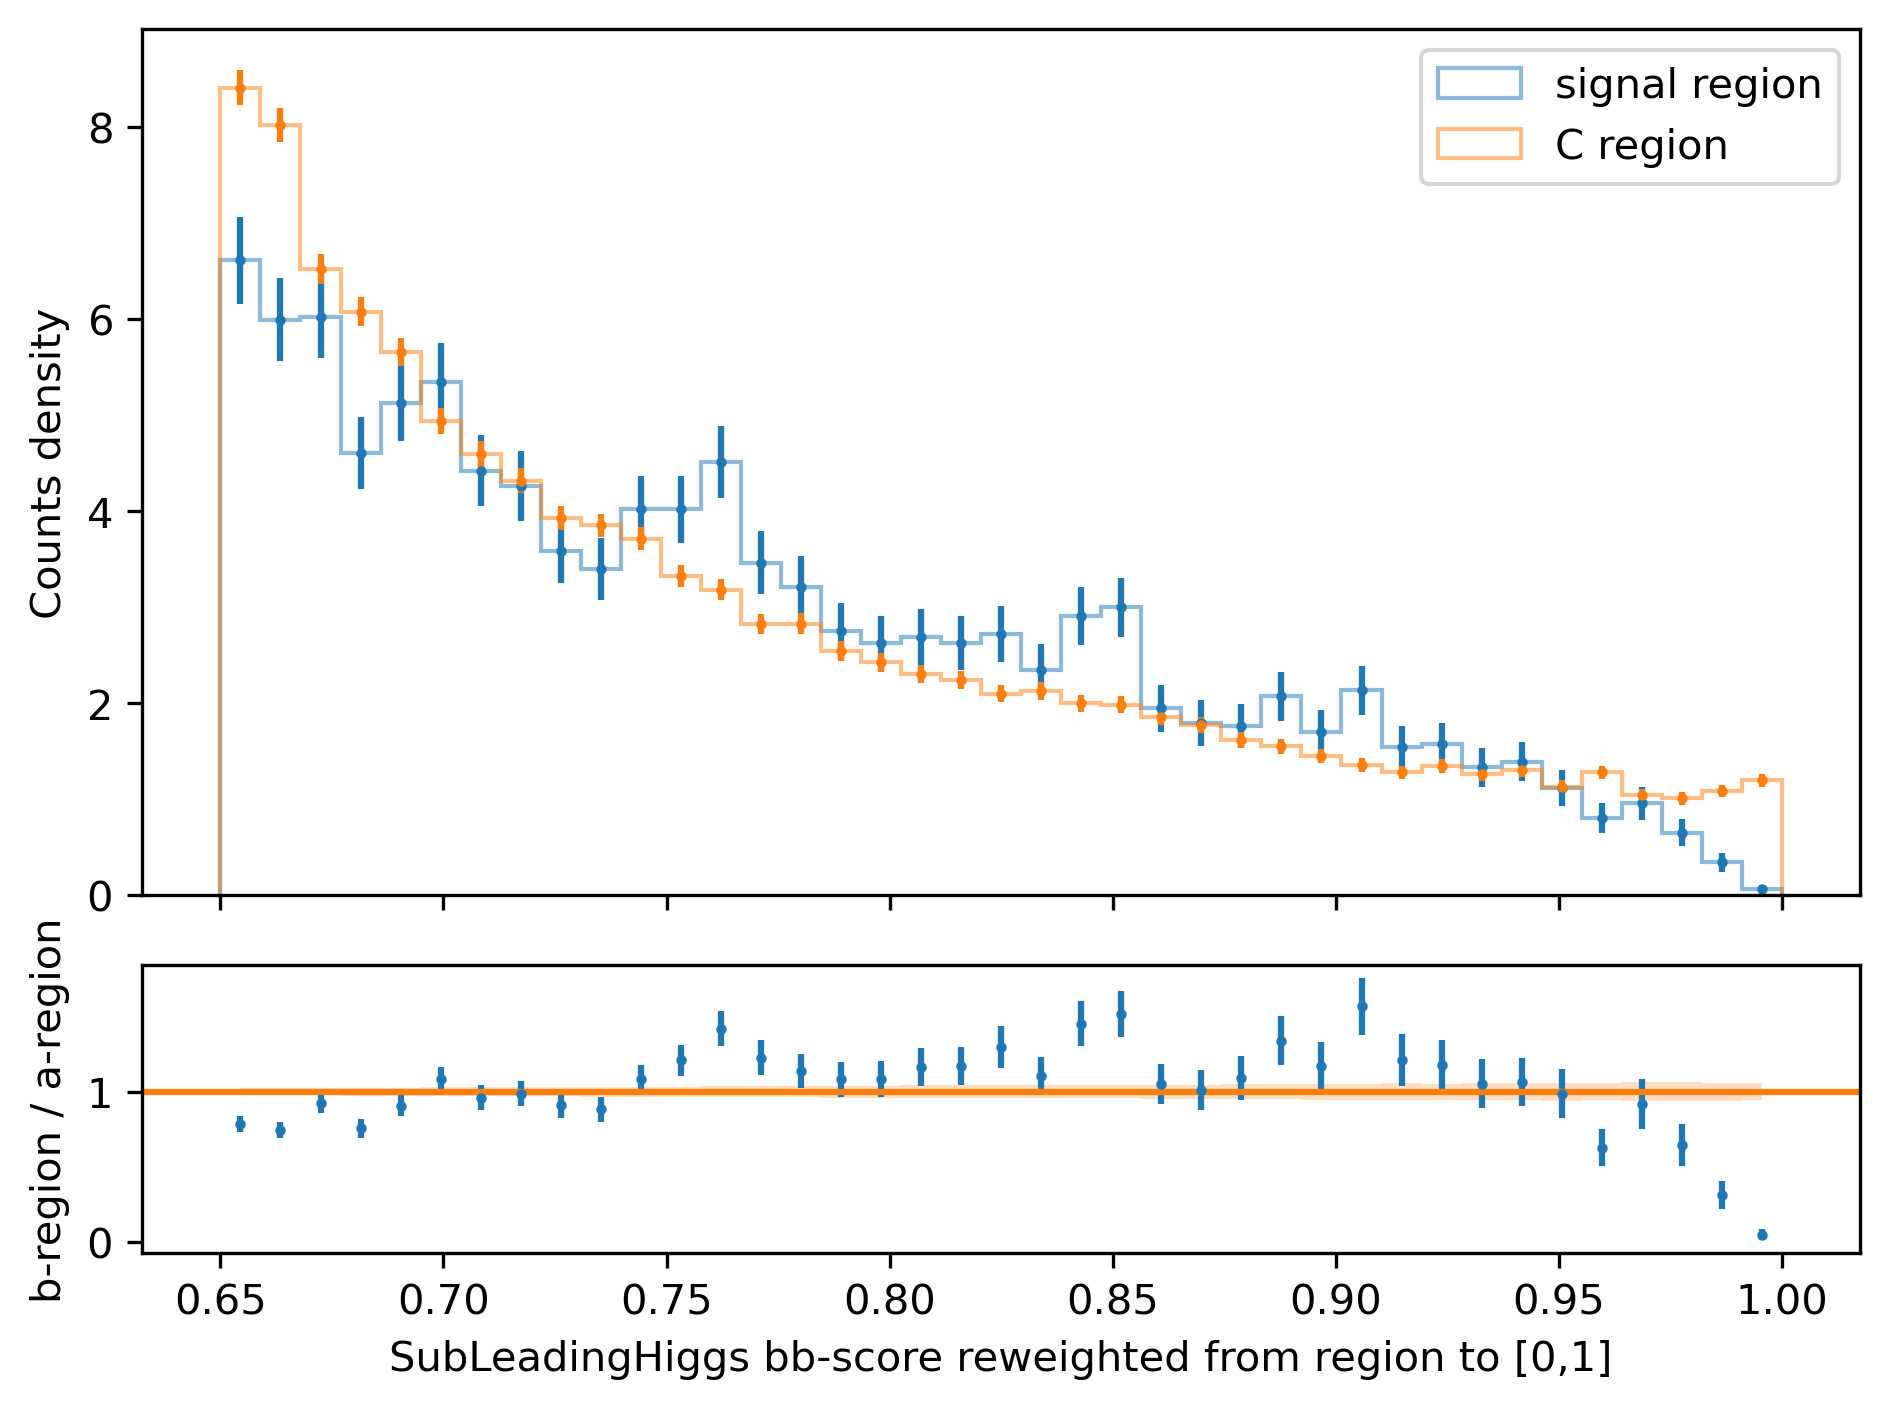

In [63]:
plot_reweighted_scores(b_bscore, a_bscore, range1=[0.65, 1], range2=[0.1, 0.65], regnames=["b-region", "a-region"], label="SubLeadingHiggs bb-score reweighted from region to [0,1]")